# 1.8.2 Least Squares and Partialling-out

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the data
file = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/wage2015_subsample_inference.csv"
df = pd.read_csv(file)

df.describe()

,wage,lwage,sex,shs,hsg,scl,clg,ad,mw,so,we,ne,exp1,exp2,exp3,exp4,occ,occ2,ind,ind2
count,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000
mean,23.410410,2.970787,0.444466,0.023301,0.243883,0.278058,0.317670,0.137087,0.259612,0.296505,0.216117,0.227767,13.760583,3.018925,8.235867,25.118038,5310.737476,11.670874,6629.154951,13.316893
std,21.003016,0.570385,0.496955,0.150872,0.429465,0.448086,0.465616,0.343973,0.438464,0.456761,0.411635,0.419432,10.609465,4.000904,14.488962,53.530225,11874.356080,6.966684,5333.443992,5.701019
min,3.021978,1.105912,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,370.000000,2.000000
25%,13.461538,2.599837,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.250000,0.125000,0.062500,1740.000000,5.000000,4880.000000,9.000000
50%,19.230769,2.956512,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,1.000000,1.000000,4040.000000,13.000000,7370.000000,14.000000
75%,27.777778,3.324236,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,21.000000,4.410000,9.261000,19.448100,5610.000000,17.000000,8190.000000,18.000000
max,528.845673,6.270697,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,47.000000,22.090000,103.823000,487.968100,100000.000000,22.000000,100000.000000,22.000000


In [3]:
# only keep individuals with at least some college education ("Some College", "College Graduate", "Advanced Degree")
college = df[(df['scl'] == 1) | (df['clg'] == 1) | (df['ad'] == 1) ]

Following some means to describe the sample.

In [4]:
table = pd.DataFrame()

cols = ["lwage", "sex", "shs", "hsg", "scl",
        "clg", "ad", "ne", "mw", "so", "we",
        "exp1", "exp2", "exp3", "exp4",
        "occ", "occ2", "ind", "ind2"
        ]

table['Variable'] = ["Log Wage", "Sex", "Less then High School",
                     "High School Graduate", "Some College",
                     "College Graduate", "Advanced Degree",
                     "Northeast", "Midwest", "South", "West",
                     "Experience 1", "Experience 2", "Experience 3", "Experience 4",
                     "Occupation 1", "Occupation 2", "Industry 1", "Industry 2"
                    ]

table['All'] = college[cols].mean().values

table['Male'] = college[college['sex'] == 0][cols].mean().values
table['Female'] = college[college['sex'] == 1][cols].mean().values

# Show results
table

,Variable,All,Male,Female
0,Log Wage,3.062748,3.099449,3.024417
1,Sex,0.489136,0.000000,1.000000
2,Less then High School,0.000000,0.000000,0.000000
3,High School Graduate,0.000000,0.000000,0.000000
4,Some College,0.379438,0.405602,0.352113
5,College Graduate,0.433492,0.436203,0.430661
6,Advanced Degree,0.187069,0.158195,0.217226
7,Northeast,0.229200,0.219917,0.238895
8,Midwest,0.249868,0.245851,0.254063
9,South,0.298357,0.303423,0.293066


In [5]:
print(table.loc[0, 'Female'] - table.loc[0, 'Male'])

-0.07503200512595765


In the sample, the difference of logwages between male and female college educated workers is even larger than for all workers overall: about 7.5% difference compared to 3.8%, despite women being relatively more educated.

Running an OLS regression only on the sex dummy confirms the result and provides a heteroscedastic standard error.

In [6]:
nocontrol_fit = smf.ols("lwage ~ sex", data=college).fit()
nocontrol_est = nocontrol_fit.params['sex']
nocontrol_se = nocontrol_fit.HC3_se['sex']

print(f"The estimated sex coefficient is {nocontrol_est:.4f} "
      f"and the corresponding robust standard error is {nocontrol_se:.4f}.")

The estimated sex coefficient is -0.0750 and the corresponding robust standard error is 0.0184.


## Full regression
Running a regression with multiple controls, the predictive effect of sec can be obtained by looking only at its coeeficient. 

In [7]:
control = "lwage ~ sex + (exp1+exp2+exp3+exp4)*(scl+clg+C(occ2)+C(ind2)+mw+so+we)"

control_fit = smf.ols(control, data=college).fit()
control_est = control_fit.params['sex']
control_se = control_fit.HC3_se['sex']

# control_fit.summary()

In [8]:
print(f"The estimated sex coefficient is {control_est:.4f} "
      f"and the corresponding robust standard error is {control_se:.4f} (standard SE: {control_fit.bse['sex']:.4f}).")

The estimated sex coefficient is -0.0676 and the corresponding robust standard error is 0.0178 (standard SE: 0.0175).


Thus, even when holding education, experience, occupation, industry, and region constant, college-educated women in this sample earn approximately 6.76% less than their male counterparts

## Partialling out
Instead of running the full regression and selecting the coefficient of interest, one can use the Frisch-Waugh-Lovell theorem as follows to directly obtain the result:

* regress logwage on controls and residualize it (i.e. keep only the part of it which cannot be explained by the controls)
* regress sex on controls and residualize it
* regress the residulaized logwage on the residualized sex

The result is the predictive effect of sex on logwages net of the effect that can be explained by the controls.


In [9]:
# Partialling-Out using ols

# models
flex_y = "lwage ~ (exp1+exp2+exp3+exp4)*(scl+clg+C(occ2)+C(ind2)+mw+so+we)"  # model for log wages Y = gamma*W + u
flex_d = "sex ~ (exp1+exp2+exp3+exp4)*(scl+clg+C(occ2)+C(ind2)+mw+so+we)"  # model for sex D = pi*W + v

# partialling-out the linear effect of W from Y (residualized log wage)
t_Y = smf.ols(flex_y, data=college).fit().resid
# partialling-out the linear effect of W from D (residualized sex)
t_D = smf.ols(flex_d, data=college).fit().resid

# regression of Y on D after partialling-out the effect of W
partial_fit = sm.OLS(t_Y, sm.add_constant(t_D)).fit()
partial_est = partial_fit.params[0]

# standard error
partial_se = partial_fit.HC3_se[0]

# confidence interval
print("95% CI: " + str(partial_fit.conf_int().values[0]))

print(f"The estimated sex coefficient is {partial_est:.4f} "
      f"and the corresponding robust standard error is {partial_se:.4f} (standard SE: {partial_fit.bse[0]:.4f}).")


95% CI: [-0.01460996  0.01460996]
The estimated sex coefficient is -0.0676 and the corresponding robust standard error is 0.0168 (standard SE: 0.0169).


As expected, the estimates coincide. However, even the standard SE are not exactly the same. Probaly manual partialling-out slightly underestimates the standard error because the second-stage regression doesn't know how many degrees of freedom were used up by the controls in the first stage.

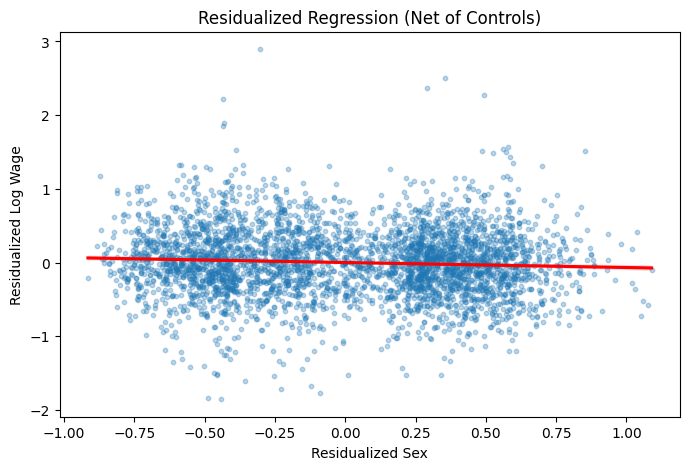

In [10]:
plt.figure(figsize=(8, 5))
sns.regplot(x=t_D, y=t_Y, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title("Residualized Regression (Net of Controls)")
plt.xlabel("Residualized Sex")
plt.ylabel("Residualized Log Wage")
plt.show()

The plot shows the second stage regression after partialling out the ceffect of the controls. The slope of the resulting regression line visually represents the isolated wage penalty for college-educated women.

## Experiment: Does an advanced degree affect the gender wage gap?
As a short exercise, consider the effect of an advanced degree on the gender wage gap among college-educated women.

In [ ]:
interaction_formula = "lwage ~ sex * ad + (exp1+exp2+exp3+exp4)*(C(occ2)+C(ind2)+mw+so+we)"

interaction_fit = smf.ols(interaction_formula, data=college).fit()
# print(interaction_fit.summary().tables[1])
print("The interaction coefficient is: " + str(interaction_fit.params['sex:ad']) + 
    " with robust standard error: " + str(interaction_fit.HC3_se['sex:ad']))

The interaction coefficient is: -0.05251628760727427 with robust standard error: 0.04609387185665307


The additional wage penalty in this specification for women with an advanced degree compared to women who only have (some) college degree is -5%, but not significant. Here controls have the same effect for all educational levels.